<a href="https://colab.research.google.com/github/leosanjit10/sales_data_analysis_dashboard/blob/main/Untitled12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/datasets/superstore_sales_dataset.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
from numpy import int64
# convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst = True)

# convert postal code
df['Postal Code'] = df['Postal Code'].astype('Int64')

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Exploratory Data Analysis (EDA)
total_sales = df ["Sales"].sum()
print(f"Total Sales: {total_sales}")

Total Sales: 2261536.7827000003


In [ ]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [ ]:
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [ ]:
avg_order_value = total_sales / total_orders
print(f"Average Order Value: ${avg_order_value:,.2f}")

Average Order Value: $459.48


In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(sales_by_region)
# business question : which region generates the most revenue
# -- west region generates m0ost revenue --

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [ ]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(sales_by_category)
 # business question: Which category contributes the most sales?
 # -- technology contibutes the most sales --

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [ ]:
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

print(sales_by_subcategory)
# business question : Which products/categories are driving revenue?
# -- phones are driving revenue --

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


In [ ]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
    .sum()
)

print(monthly_sales)
# business question : are sales increasing or decreasing over time?

Order Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040


Monthly sales fluctuate significantly throughout the year.
Sales tend to spike in September, November, and December.
Overall revenue grows from 2015 to 2018.
The highest monthly sales were recorded in November 2018 ($117,938.16).

In [ ]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [ ]:
avg_shipping = df['Shipping Days'].mean()

print(avg_shipping)
# business question : how long does shipping usually takes
# -- it takes 3.96 days to ship on average --

3.9611224489795918


In [ ]:
# KPI 1      (KEY PERFORMANCE INDICATOR)
total_sales = df['Sales'].sum()
print(f"total_sales: ${total_sales:,.2f}")

# KPI 2
total_orders = df['Order ID'].nunique()
print(f"Total Orders:" ,{total_orders})

# KPI 3
total_customers = df['Customer ID'].nunique()
print(f"Total Customers:" ,{total_customers})

# KPI 4
avg_order_value = total_sales / total_orders
print(f"Average Order Value: ${avg_order_value:,.2f}")




total_sales: $2,261,536.78
Total Orders: {4922}
Total Customers: {793}
Average Order Value: $459.48


In [ ]:
df.shape


(9800, 21)

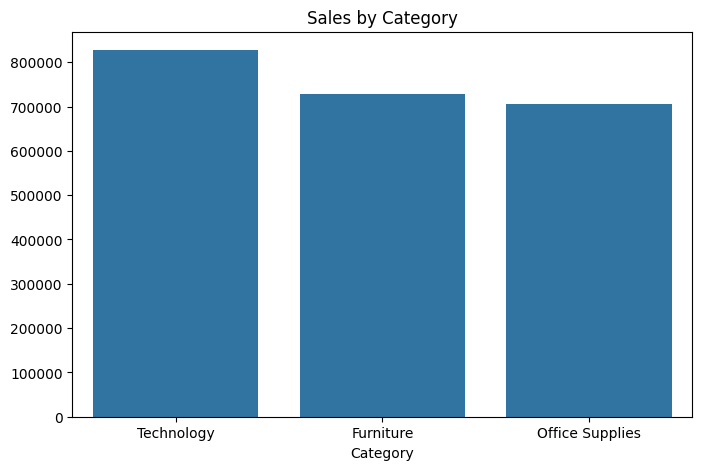

In [ ]:
# sales by category
import seaborn as sns
import matplotlib.pyplot as plt

sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=sales_category.index, y=sales_category.values)
plt.title('Sales by Category')
plt.savefig('sales_by_category.png', bbox_inches='tight')
plt.show()

***Insight***

Technology generated the highest sales revenue at approximately $830K, making it the strongest-performing product category.

Furniture generated around $730K in sales and ranked second among all categories.

Office Supplies generated approximately $710K in sales, placing third but still contributing significantly to overall revenue.

Sales are relatively balanced across categories, indicating that the business has a diversified revenue stream rather than relying on a single category.

The gap between Technology and the other categories suggests higher customer demand for technology-related products.

***Business Recommendation***

Increase inventory availability and marketing efforts for Technology products to capitalize on strong customer demand.

Analyze top-selling Technology products to identify opportunities for upselling and cross-selling.

Develop promotional campaigns for Furniture and Office Supplies to narrow the sales gap and drive additional revenue.

Monitor category-level performance regularly to ensure resources are allocated to the most profitable and high-growth product segments.

Consider expanding the product range within the Technology category, as it demonstrates the greatest revenue potential.

***Key Takeaway***

Technology is the company's strongest revenue-generating category, while Furniture and Office Supplies provide stable supporting sales.

 Strategic investment in high-performing Technology products combined with targeted promotions in the other categories can help maximize overall sales growth.

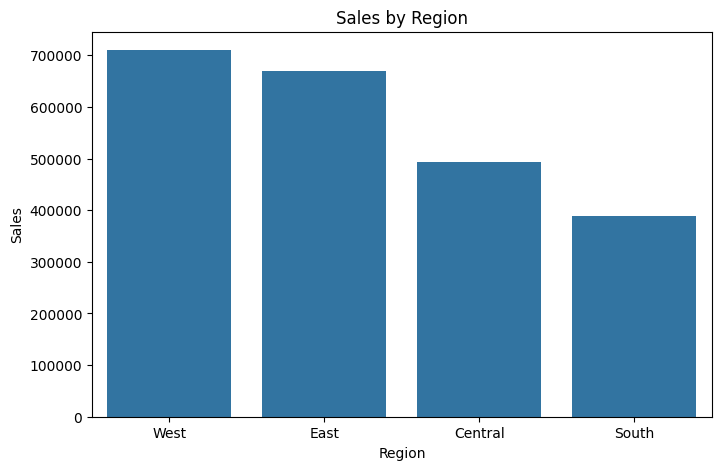

In [ ]:
# sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.savefig('sales_by_region.png', bbox_inches='tight')
plt.show()

## Insight
The West region generated the highest sales revenue at approximately $710K, making it the strongest-performing market.
The East region closely followed with around $670K in sales, indicating strong customer demand and market presence.
The Central region generated approximately $495K, significantly lower than both the West and East regions.
The South region recorded the lowest sales at approximately $390K, suggesting weaker market performance compared to other regions.
Sales performance varies noticeably across regions, indicating potential differences in customer demand, market penetration, product availability, or marketing effectiveness.
## Business Recommendation
Continue investing in the West and East regions, as they are the primary revenue drivers and offer opportunities for further growth.
Analyze successful strategies used in the West region and replicate them in underperforming regions where appropriate.
Conduct a deeper investigation into the South region to identify barriers to sales growth, such as limited product demand, insufficient marketing, or distribution challenges.
Develop targeted marketing campaigns and promotional offers in the Central and South regions to increase customer engagement and sales volume.
Consider allocating additional resources, sales staff, or inventory to regions with high growth potential while maintaining support for top-performing markets.
## Key Takeaway

The West and East regions are the company's strongest markets, generating the majority of sales revenue. The Central and South regions represent growth opportunities, and targeted business strategies in these areas could help balance regional performance and increase overall revenue.

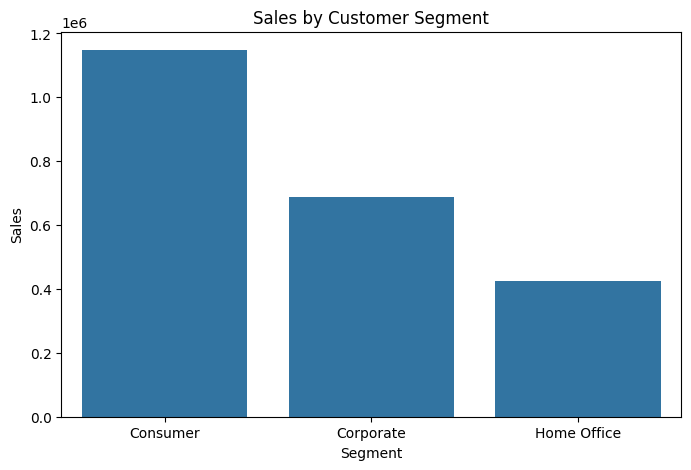

In [ ]:
# sales by customer segment
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.savefig('sales_by_customer_segment', bbox_inches='tight')
plt.show()

## Insight

- The **Consumer** segment generated the highest sales revenue at approximately **$1.15M**, accounting for nearly half of total sales.
- The **Corporate** segment contributed around **$690K** in sales, making it the second-largest customer segment.
- The **Home Office** segment generated approximately **$430K** in sales and had the lowest contribution among all segments.
- Sales from the Consumer segment are significantly higher than those from Corporate and Home Office customers, indicating that individual consumers are the primary drivers of business revenue.
- The large gap between Consumer and Home Office sales suggests an opportunity to expand sales efforts toward smaller business and home office customers.

## Business Recommendation

- Prioritize marketing campaigns and customer retention strategies for the **Consumer** segment, as it represents the company's largest revenue source.
- Develop personalized promotions, loyalty programs, and targeted offers to increase repeat purchases among Consumer customers.
- Explore growth opportunities within the **Corporate** segment through bulk-purchase discounts, business partnerships, and account-based marketing.
- Implement initiatives aimed at increasing engagement with **Home Office** customers, such as special offers, bundled products, or dedicated product recommendations.
- Conduct further analysis to identify the highest-value customers within each segment and tailor sales strategies accordingly.

## Key Takeaway

> The **Consumer segment is the dominant revenue driver**, generating substantially more sales than Corporate and Home Office customers. While maintaining strong relationships with Consumer customers should remain a priority, the company has significant opportunities to increase revenue by expanding its presence in the Corporate and Home Office markets.

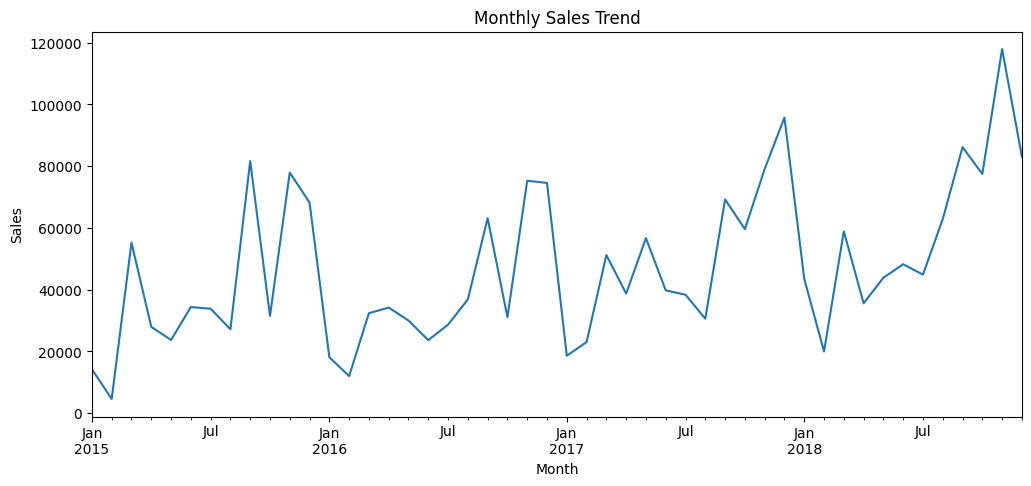

In [ ]:
# monthly sales trend
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.savefig('monthly_sales_trend.png', bbox_inches='tight')
plt.show()

## Insight

- Sales show an overall upward trend from 2015 to 2018, indicating sustained business growth over the analyzed period.
- Monthly sales fluctuate significantly, suggesting the presence of seasonality and varying customer demand throughout the year.
- Several sales peaks exceed $80K, with the highest peak reaching approximately $118K toward the end of 2018.
- Sales tend to be stronger during the final months of the year, indicating increased purchasing activity during the holiday and year-end season.
- Despite periodic declines, each year generally achieves higher sales levels than the previous year, demonstrating positive long-term growth.

## Business Recommendation

- Prepare inventory, staffing, and marketing budgets in advance of peak sales periods to maximize revenue opportunities.
- Develop targeted promotional campaigns during lower-performing months to reduce sales volatility and maintain a more consistent revenue stream.
- Analyze the factors contributing to year-end sales spikes and replicate successful strategies throughout the year when possible.
- Implement sales forecasting models to improve inventory planning and resource allocation during high-demand periods.
- Continue investing in growth initiatives, as the long-term upward trend suggests strong market demand and expansion potential.

## Key Takeaway

> The business demonstrates strong long-term growth with clear seasonal sales patterns. Sales consistently increase over time, with the highest revenue occurring during year-end periods. Effective forecasting and seasonal planning can help the company capitalize on peak demand while minimizing fluctuations during slower months.

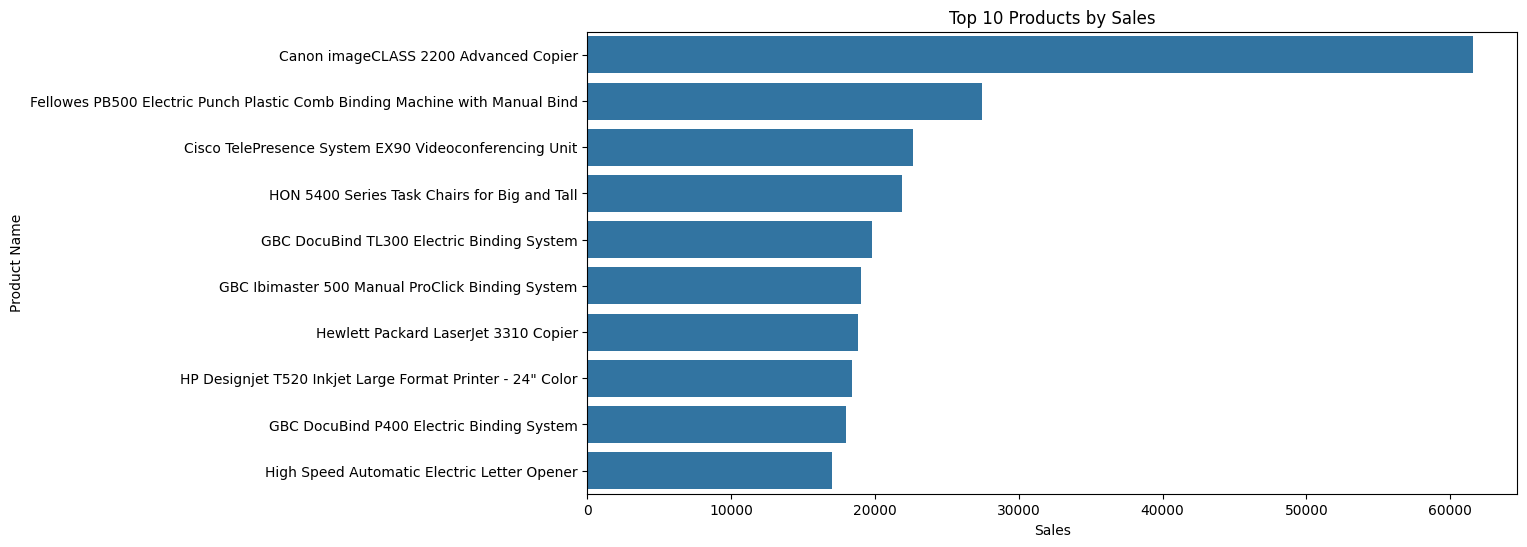

In [ ]:
# top 10 products by sales
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.savefig('top_products.png', bbox_inches='tight')
plt.show()

## Insight

- The **Canon imageCLASS 2200 Advanced Copier** is the top-selling product by a significant margin, generating approximately **$62K** in sales, making it the strongest revenue contributor in the product portfolio.
- The **Fellowes PB500 Electric Punch Plastic Comb Binding Machine** ranks second with roughly **$27K** in sales, less than half of the top product's sales.
- Several products in the top 10 list are office equipment, copiers, printers, and binding systems, indicating strong customer demand for business and office-related products.
- The sales distribution among the second through tenth ranked products is relatively close, suggesting a balanced performance across multiple high-selling products.
- Revenue appears to be concentrated among a small group of high-value products, demonstrating the importance of tracking top-performing items and maintaining inventory availability.

## Business Recommendation

- Ensure sufficient inventory levels for the **Canon imageCLASS 2200 Advanced Copier** to prevent stockouts and lost sales opportunities.
- Analyze the characteristics and customer demographics associated with top-selling products to identify opportunities for cross-selling and upselling.
- Develop targeted marketing campaigns featuring best-selling products to attract new customers and increase revenue.
- Monitor product performance regularly and replicate successful pricing, promotion, or positioning strategies across similar products.
- Reduce dependence on a small number of top revenue-generating products by promoting complementary products and expanding sales across a broader product range.

## Key Takeaway

> A small group of office technology and equipment products generates a substantial portion of total revenue. Maintaining product availability, leveraging top-performing products in marketing campaigns, and promoting related products can help drive continued sales growth.


In [ ]:
df.to_csv('clean_sales_data.csv', index=False)